# TF-IDF + Logistic Regression

In [ ]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("bethesda-classification")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

## Служебная информация об эксперименте

Фиксируем имя участника, название задачи, дату и текущий Git commit.

Git commit используется как идентификатор версии кода. Перед запуском модели
необходимо убедиться, что код эксперимента закоммичен. Если в рабочей директории
есть незакоммиченные изменения, текущий commit не полностью описывает состояние
кода, на котором выполняется эксперимент.

In [17]:
import subprocess
from datetime import datetime


participant = "Savely"
task_name = "bethesda-classification"

# Получаем SHA текущего Git-коммита
git_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    text=True,
).strip()

# Проверяем наличие незакоммиченных изменений
git_status = subprocess.check_output(
    ["git", "status", "--porcelain"],
    text=True,
).strip()

run_date = datetime.now().strftime("%d-%m-%Y")

print("Participant:", participant)
print("Task:", task_name)
print("Date:", run_date)
print("Git commit:", git_commit)

if git_status:
    print("\nWARNING: в репозитории есть незакоммиченные изменения.")
    print("Перед первым MLflow run необходимо сделать commit и повторно выполнить эту ячейку.")
else:
    print("\nGit working tree clean.")

Participant: Savely
Task: bethesda-classification
Date: 11-10-2026
Git commit: 038e4d8f2b3d8790c0e74aa5ce3f87cb0b16a4e5

Git working tree clean.


## Версия датасета

Для экспериментов используется актуальный `prepared_dataset.csv`.

Версия данных определяется полным SHA256-хешем файла. Если содержимое датасета
изменится хотя бы на уровне одного байта, изменится и его SHA256.

Полный SHA256 будет сохраняться в каждом MLflow run как `dataset_version`.
Первые 12 символов используются только для удобного отображения и имени
архивной копии датасета.

In [3]:
from pathlib import Path

from src.common.dataset_versioning import calculate_sha256


# Определяем корень проекта
PROJECT_ROOT = Path.cwd().resolve()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = next(
        path
        for path in PROJECT_ROOT.parents
        if (path / "src").exists()
    )

# Актуальный воспроизводимый датасет
dataset_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "prepared_dataset.csv"
)

if not dataset_path.exists():
    raise FileNotFoundError(
        f"Датасет не найден: {dataset_path}"
    )

# Вычисляем версию данных
dataset_hash = calculate_sha256(dataset_path)
dataset_version_short = dataset_hash[:12]

# Ожидаемая архивная копия этой версии
dataset_version_path = (
    dataset_path.parent
    / "versions"
    / f"{dataset_path.stem}_{dataset_version_short}{dataset_path.suffix}"
)

print("Dataset:", dataset_path.name)
print("Dataset version:", dataset_version_short)
print("Full SHA256:", dataset_hash)
print("Archived version:", dataset_version_path.name)
print("Archive exists:", dataset_version_path.exists())

Dataset: prepared_dataset.csv
Dataset version: e88b34b729ea
Full SHA256: e88b34b729eaf057b6f2a7deeae7fcfce901da710ddce628a329d9d96aaad724
Archived version: prepared_dataset_e88b34b729ea.csv
Archive exists: True


## Загрузка и первичная проверка датасета

Загрузим актуальный `prepared_dataset.csv`, для которого выше был вычислен
SHA256-хеш.

Проверим размер датасета, структуру столбцов и первые строки. На этом этапе
модель ещё не обучается, поэтому отдельный MLflow run не создаётся.

In [8]:
import pandas as pd

df = pd.read_csv(dataset_path, sep=";")

print("Путь к датасету:", dataset_path)
print("Размер датасета:", df.shape)
print("Столбцы:", df.columns.tolist())

Путь к датасету: /Users/savely/Desktop/diploma/data/processed/prepared_dataset.csv
Размер датасета: (5613, 8)
Столбцы: ['case_id', 'source_table', 'source_row', 'description', 'conclusion', 'bethesda', 'duplicate_group', 'duplicate_type']


## Проверка структуры и качества данных

Перед построением модели проверим:

- наличие необходимых столбцов;
- количество пропущенных значений;
- число объектов каждого класса Bethesda;
- долю каждого класса в датасете.

Это позволит оценить состояние нового датасета и степень дисбаланса классов
перед разделением на train и test.

In [5]:
print("Столбцы:")
print(df.columns.tolist())

print("\nПропущенные значения:")
print(df.isna().sum())

print("\nКоличество объектов каждого класса Bethesda:")
print(df["bethesda"].value_counts().sort_index())

print("\nДоля каждого класса:")
print(
    df["bethesda"]
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

Столбцы:
['case_id', 'source_table', 'source_row', 'description', 'conclusion', 'bethesda', 'duplicate_group', 'duplicate_type']

Пропущенные значения:
case_id               0
source_table          0
source_row            0
description           0
conclusion            0
bethesda              0
duplicate_group    5603
duplicate_type     5603
dtype: int64

Количество объектов каждого класса Bethesda:
bethesda
I       575
II     3825
III     286
IV      559
V       172
VI      196
Name: count, dtype: int64

Доля каждого класса:
bethesda
I      0.1024
II     0.6815
III    0.0510
IV     0.0996
V      0.0306
VI     0.0349
Name: proportion, dtype: float64


## Проверка дубликатов

В актуальном датасете информация о найденных дубликатах сохраняется в полях
`duplicate_group` и `duplicate_type`.

Дубликаты не удаляются автоматически на этапе подготовки данных. Перед обучением
необходимо проверить найденные группы и исключить ситуацию, когда одинаковые
описания попадают одновременно в обучающую и тестовую выборки.

Дополнительно проверим уникальность `case_id`, наличие полных дубликатов строк
и повторяющихся значений `description`.

In [6]:
# Проверяем уникальность идентификаторов
duplicate_case_ids = df["case_id"].duplicated().sum()

# Проверяем полные дубликаты строк
duplicate_rows = df.duplicated().sum()

# Проверяем одинаковые description
duplicate_descriptions = df["description"].duplicated().sum()

# Выбираем записи, для которых задана группа дубликатов
marked_duplicates = df[
    df["duplicate_group"].notna()
].copy()

print("Дубликаты case_id:", duplicate_case_ids)
print("Полные дубликаты строк:", duplicate_rows)
print("Повторяющиеся description:", duplicate_descriptions)

print("\nСтрок с duplicate_group:", len(marked_duplicates))
print(
    "Количество групп дубликатов:",
    marked_duplicates["duplicate_group"].nunique()
)

print("\nТипы дубликатов:")
print(
    marked_duplicates["duplicate_type"]
    .value_counts(dropna=False)
)

Дубликаты case_id: 0
Полные дубликаты строк: 0
Повторяющиеся description: 0

Строк с duplicate_group: 10
Количество групп дубликатов: 10

Типы дубликатов:
duplicate_type
technical    10
Name: count, dtype: int64


## Разделение данных на обучающую и тестовую выборки

Для классификации используется только поле `description`.
Поле `bethesda` является целевой переменной.

Служебные поля `case_id`, `source_table`, `source_row`, `duplicate_group`
и `duplicate_type`, а также поле `conclusion`, в признаки модели не включаются.

Перед разделением было подтверждено отсутствие повторяющихся `description`,
поэтому одинаковые тексты не могут одновременно попасть в train и test.

Данные разделяются в отношении 80/20 со стратификацией по Bethesda.
Параметр `random_state=42` фиксируется для воспроизводимости эксперимента.

In [11]:
from sklearn.model_selection import train_test_split


# Вход модели - только цитологическое описание
X = df["description"]

# Целевая переменная - категория Bethesda
y = df["bethesda"]

# Стратифицированное разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Размер всей выборки:", len(X))
print("Размер train:", len(X_train))
print("Размер test:", len(X_test))

print("\nРаспределение классов в train:")
print(y_train.value_counts().sort_index())

print("\nРаспределение классов в test:")
print(y_test.value_counts().sort_index())

Размер всей выборки: 5613
Размер train: 4490
Размер test: 1123

Распределение классов в train:
bethesda
I       460
II     3060
III     229
IV      447
V       137
VI      157
Name: count, dtype: int64

Распределение классов в test:
bethesda
I      115
II     765
III     57
IV     112
V       35
VI      39
Name: count, dtype: int64


## Первый baseline: TF-IDF + Logistic Regression

В качестве первого воспроизводимого baseline используется комбинация
`TF-IDF + Logistic Regression`.

Параметры первого запуска намеренно оставляются простыми:

- `ngram_range=(1, 1)` - используются отдельные слова;
- `min_df=2` - исключаются термины, встретившиеся только в одном документе;
- `lowercase=True` - текст приводится к нижнему регистру;
- `class_weight=None` - балансировка классов не используется;
- `max_iter=1000` - увеличено максимальное число итераций для сходимости;
- `random_state=42` - фиксируется для воспроизводимости.

Этот запуск будет использоваться как базовая точка для сравнения последующих
вариантов модели.

In [12]:
# Параметры TF-IDF для первого baseline
tfidf_params = {
    "ngram_range": (1, 1),
    "min_df": 2,
    "lowercase": True,
}

# Параметры Logistic Regression
logreg_params = {
    "max_iter": 1000,
    "random_state": 42,
    "class_weight": None,
}

print("TF-IDF parameters:")
print(tfidf_params)

print("\nLogistic Regression parameters:")
print(logreg_params)

TF-IDF parameters:
{'ngram_range': (1, 1), 'min_df': 2, 'lowercase': True}

Logistic Regression parameters:
{'max_iter': 1000, 'random_state': 42, 'class_weight': None}


In [18]:
# Проверка перед запуском модели
print("Git commit:", git_commit)
print("Dataset SHA256:", dataset_hash)
print("MLflow tracking URI:", mlflow.get_tracking_uri())

# Дополнительная проверка доступности MLflow server
try:
    mlflow.search_experiments()
    print("MLflow server: доступен")
except Exception as error:
    print("MLflow server: недоступен")
    print("Ошибка:", error)

Git commit: 038e4d8f2b3d8790c0e74aa5ce3f87cb0b16a4e5
Dataset SHA256: e88b34b729eaf057b6f2a7deeae7fcfce901da710ddce628a329d9d96aaad724
MLflow tracking URI: http://127.0.0.1:5000
MLflow server: доступен


## MLflow Run 1: TF-IDF + Logistic Regression baseline

Первый эксперимент на актуальном `prepared_dataset.csv` повторяет базовую
конфигурацию архивного эксперимента.

В одном MLflow run сохраняются:

- участник и задача;
- дата запуска;
- Git commit;
- полный SHA256 используемого датасета;
- размеры train и test;
- параметры TF-IDF и Logistic Regression;
- `macro-F1`;
- `balanced accuracy`;
- recall каждого класса Bethesda;
- confusion matrix;
- обученный Pipeline.

Модель строится как единый Pipeline:

`description` → `TF-IDF` → `Logistic Regression`.

TF-IDF обучается только на `X_train`, поэтому информация из тестовой выборки
не участвует в построении словаря и весов признаков.

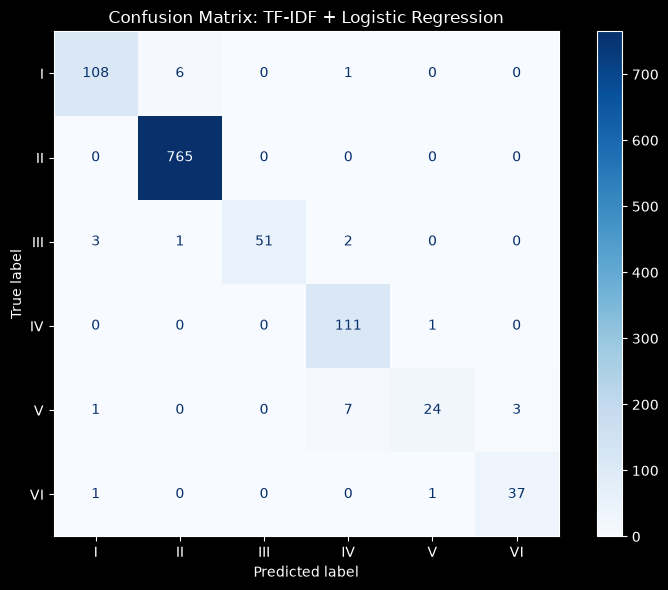

MLflow run ID: 2d73a8e5e78c41258fed4c85ea27d870

Macro-F1: 0.9273
Balanced accuracy: 0.9099

Recall каждого класса:
Bethesda I: 0.9391
Bethesda II: 1.0000
Bethesda III: 0.8947
Bethesda IV: 0.9911
Bethesda V: 0.6857
Bethesda VI: 0.9487
🏃 View run prepared_tfidf_logreg_baseline at: http://127.0.0.1:5000/#/experiments/1/runs/2d73a8e5e78c41258fed4c85ea27d870
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [15]:
import matplotlib.pyplot as plt
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    recall_score,
    ConfusionMatrixDisplay,
)


# Фиксированный порядок классов для метрик и confusion matrix
classes = ["I", "II", "III", "IV", "V", "VI"]


# Создаём единый Pipeline:
# исходный текст -> TF-IDF -> Logistic Regression
model_run1 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(**tfidf_params),
    ),
    (
        "logreg",
        LogisticRegression(**logreg_params),
    ),
])


with mlflow.start_run(
    run_name="prepared_tfidf_logreg_baseline"
) as run:

    # Общая информация об эксперименте
    mlflow.log_params({
        "participant": participant,
        "task_name": task_name,
        "run_date": run_date,
        "git_commit": git_commit,
        "dataset_name": dataset_path.name,
        "dataset_version": dataset_hash,
        "model_name": "TF-IDF + Logistic Regression",
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_size_ratio": 0.2,
        "split_random_state": 42,
    })

    # Параметры TF-IDF
    mlflow.log_params({
        "tfidf_ngram_range": str(
            tfidf_params["ngram_range"]
        ),
        "tfidf_min_df": tfidf_params["min_df"],
        "tfidf_lowercase": tfidf_params["lowercase"],
    })

    # Параметры Logistic Regression
    mlflow.log_params({
        "logreg_max_iter": logreg_params["max_iter"],
        "logreg_random_state": logreg_params["random_state"],
        "logreg_class_weight": str(
            logreg_params["class_weight"]
        ),
    })

    # Обучаем модель только на train
    model_run1.fit(X_train, y_train)

    # Получаем предсказания для test
    y_pred_run1 = model_run1.predict(X_test)

    # Основные метрики
    macro_f1_run1 = f1_score(
        y_test,
        y_pred_run1,
        average="macro",
    )

    balanced_acc_run1 = balanced_accuracy_score(
        y_test,
        y_pred_run1,
    )

    # Recall отдельно для каждого класса Bethesda
    recall_per_class_run1 = recall_score(
        y_test,
        y_pred_run1,
        labels=classes,
        average=None,
        zero_division=0,
    )

    # Сохраняем основные метрики
    mlflow.log_metric(
        "macro_f1",
        macro_f1_run1,
    )

    mlflow.log_metric(
        "balanced_accuracy",
        balanced_acc_run1,
    )

    # Сохраняем recall каждого класса
    for class_name, recall_value in zip(
        classes,
        recall_per_class_run1,
    ):
        mlflow.log_metric(
            f"recall_bethesda_{class_name}",
            recall_value,
        )

    # Строим confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_run1,
        labels=classes,
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    ax.set_title(
        "Confusion Matrix: TF-IDF + Logistic Regression"
    )

    plt.tight_layout()

    # Сохраняем confusion matrix в MLflow
    mlflow.log_figure(
        fig,
        "confusion_matrix.png",
    )

    plt.show()
    plt.close(fig)

    # Сохраняем весь обученный Pipeline
    mlflow.sklearn.log_model(
        sk_model=model_run1,
        name="model",
    )

    print("MLflow run ID:", run.info.run_id)
    print()
    print(f"Macro-F1: {macro_f1_run1:.4f}")
    print(
        f"Balanced accuracy: "
        f"{balanced_acc_run1:.4f}"
    )

    print("\nRecall каждого класса:")

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run1,
    ):
        print(
            f"Bethesda {class_name}: "
            f"{recall_value:.4f}"
        )

## Результаты baseline

Первый воспроизводимый baseline `TF-IDF + Logistic Regression` на
`prepared_dataset.csv` показал следующие результаты:

- `macro-F1 = 0.9273`;
- `balanced accuracy = 0.9099`.

Модель хорошо распознаёт большинство классов Bethesda. Наиболее высокий recall
получен для Bethesda II и IV.

Наиболее слабым классом является Bethesda V:

- recall Bethesda V = `0.6857`;
- из 35 объектов класса V правильно классифицированы 24;
- 7 объектов были отнесены к Bethesda IV;
- 3 объекта - к Bethesda VI;
- 1 объект - к Bethesda I.

Одной из возможных причин является выраженный дисбаланс классов: Bethesda II
составляет большую часть обучающей выборки, тогда как Bethesda V представлен
значительно меньшим количеством объектов.

Следующий эксперимент проверяет, улучшит ли автоматическая балансировка весов
классов распознавание редких категорий.

## Эксперимент 2: Logistic Regression с балансировкой классов

Во втором эксперименте изменяется только параметр `class_weight` модели
Logistic Regression:

`None` → `"balanced"`.

Параметры TF-IDF, train/test split и `random_state` остаются неизменными.

При `class_weight="balanced"` веса классов рассчитываются обратно
пропорционально количеству объектов каждого класса в обучающей выборке.
Ошибки на редких классах получают больший вес при оптимизации модели.

Цель эксперимента - проверить, повысится ли качество распознавания редких
категорий Bethesda, прежде всего Bethesda V, без существенного ухудшения
общего качества классификации.

In [16]:
# TF-IDF оставляем без изменений
tfidf_params_run2 = {
    "ngram_range": (1, 1),
    "min_df": 2,
    "lowercase": True,
}

# Единственное изменение - балансировка классов
logreg_params_run2 = {
    "max_iter": 1000,
    "random_state": 42,
    "class_weight": "balanced",
}

print("TF-IDF parameters:")
print(tfidf_params_run2)

print("\nLogistic Regression parameters:")
print(logreg_params_run2)

TF-IDF parameters:
{'ngram_range': (1, 1), 'min_df': 2, 'lowercase': True}

Logistic Regression parameters:
{'max_iter': 1000, 'random_state': 42, 'class_weight': 'balanced'}


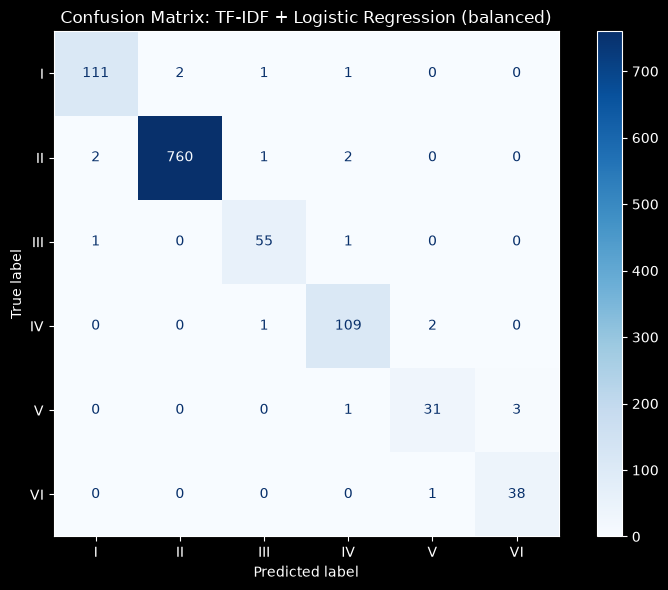

MLflow run ID: ece9684356524facb8a7f2a5d3b9f1d4

Macro-F1: 0.9558
Balanced accuracy: 0.9595

Recall каждого класса:
Bethesda I: 0.9652
Bethesda II: 0.9935
Bethesda III: 0.9649
Bethesda IV: 0.9732
Bethesda V: 0.8857
Bethesda VI: 0.9744
🏃 View run prepared_tfidf_logreg_balanced at: http://127.0.0.1:5000/#/experiments/1/runs/ece9684356524facb8a7f2a5d3b9f1d4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [19]:
# Создаём Pipeline для второго эксперимента
model_run2 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(**tfidf_params_run2),
    ),
    (
        "logreg",
        LogisticRegression(**logreg_params_run2),
    ),
])


with mlflow.start_run(
    run_name="prepared_tfidf_logreg_balanced"
) as run:

    # Общая информация об эксперименте
    mlflow.log_params({
        "participant": participant,
        "task_name": task_name,
        "run_date": run_date,
        "git_commit": git_commit,
        "dataset_name": dataset_path.name,
        "dataset_version": dataset_hash,
        "model_name": "TF-IDF + Logistic Regression",
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_size_ratio": 0.2,
        "split_random_state": 42,
    })

    # Параметры TF-IDF
    mlflow.log_params({
        "tfidf_ngram_range": str(
            tfidf_params_run2["ngram_range"]
        ),
        "tfidf_min_df": tfidf_params_run2["min_df"],
        "tfidf_lowercase": tfidf_params_run2["lowercase"],
    })

    # Параметры Logistic Regression
    mlflow.log_params({
        "logreg_max_iter": logreg_params_run2["max_iter"],
        "logreg_random_state": logreg_params_run2["random_state"],
        "logreg_class_weight": logreg_params_run2["class_weight"],
    })

    # Обучение
    model_run2.fit(X_train, y_train)

    # Предсказания
    y_pred_run2 = model_run2.predict(X_test)

    # Метрики
    macro_f1_run2 = f1_score(
        y_test,
        y_pred_run2,
        average="macro",
    )

    balanced_acc_run2 = balanced_accuracy_score(
        y_test,
        y_pred_run2,
    )

    recall_per_class_run2 = recall_score(
        y_test,
        y_pred_run2,
        labels=classes,
        average=None,
        zero_division=0,
    )

    # Логируем метрики
    mlflow.log_metric(
        "macro_f1",
        macro_f1_run2,
    )

    mlflow.log_metric(
        "balanced_accuracy",
        balanced_acc_run2,
    )

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run2,
    ):
        mlflow.log_metric(
            f"recall_bethesda_{class_name}",
            recall_value,
        )

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_run2,
        labels=classes,
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    ax.set_title(
        "Confusion Matrix: TF-IDF + Logistic Regression (balanced)"
    )

    plt.tight_layout()

    mlflow.log_figure(
        fig,
        "confusion_matrix.png",
    )

    plt.show()
    plt.close(fig)

    # Сохраняем Pipeline целиком
    mlflow.sklearn.log_model(
        sk_model=model_run2,
        name="model",
    )

    print("MLflow run ID:", run.info.run_id)
    print()
    print(f"Macro-F1: {macro_f1_run2:.4f}")
    print(
        f"Balanced accuracy: "
        f"{balanced_acc_run2:.4f}"
    )

    print("\nRecall каждого класса:")

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run2,
    ):
        print(
            f"Bethesda {class_name}: "
            f"{recall_value:.4f}"
        )

## Сравнение экспериментов 1 и 2

Во втором эксперименте было изменено только значение `class_weight`
в Logistic Regression:

`None` → `"balanced"`.

Параметры TF-IDF, train/test split и `random_state` оставались неизменными,
поэтому различия результатов можно связать с применением балансировки классов.

| Метрика | Baseline | Balanced |
|---|---:|---:|
| Macro-F1 | 0.9273 | 0.9558 |
| Balanced accuracy | 0.9099 | 0.9595 |

Балансировка улучшила качество распознавания большинства редких классов:

- Bethesda I: recall `0.9391 → 0.9652`;
- Bethesda III: `0.8947 → 0.9649`;
- Bethesda V: `0.6857 → 0.8857`;
- Bethesda VI: `0.9487 → 0.9744`.

Наиболее значительное улучшение наблюдается для Bethesda V:
recall увеличился на `0.2000`. В baseline из 35 тестовых объектов класса V
правильно определялись 24, после балансировки - 31.

При этом recall Bethesda II немного снизился с `1.0000` до `0.9935`,
а Bethesda IV - с `0.9911` до `0.9732`.

Такое изменение соответствует ожидаемому действию `class_weight="balanced"`:
ошибки на менее представленных классах получают больший вес при обучении,
за счёт чего модель меньше ориентируется на преобладающие классы.

По совокупности `macro-F1`, `balanced accuracy` и recall редких категорий
вариант с `class_weight="balanced"` является лучшим из двух текущих экспериментов.